# Ejemplo práctico de un estudio NO supervisado con comparación de modelos

---

## Dataset elegido: Seeds (UCI Machine Learning Repository)

**Autor:** Pablo  
**Tipo de problema:** aprendizaje no supervisado con apoyo de etiquetas reales para evaluación posterior  
**Objetivo:** comprobar si, sin entrenar directamente un clasificador supervisado, somos capaces de recuperar las tres variedades de trigo presentes en el dataset a partir de sus propiedades geométricas, comparando varios algoritmos de clustering y analizando la importancia de las variables.

---

# 0 - Instalaciones necesarias e importación de librerías utilizadas

## 0.1 - Instalación de librerías

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn scipy jinja2 ipython

Note: you may need to restart the kernel to use updated packages.


## 0.2 - Importación de librerías y configuración general

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler

from scipy.optimize import linear_sum_assignment

sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.max_columns = 100
plt.rcParams["figure.figsize"] = (10, 6)

SEMILLA = 42
np.random.seed(SEMILLA)

# 1 - Carga, preparación y EDA de los datos

## 1.1 - Contexto del dataset

El dataset **Seeds** recoge mediciones geométricas de granos de trigo correspondientes a **tres variedades**:

- Kama,
- Rosa,
- Canadian.

Cada observación contiene **7 variables numéricas** y el problema es adecuado para un estudio no supervisado porque:

1. las clases son compactas y relativamente separables;
2. todas las variables son continuas;
3. el número de observaciones es manejable y permite interpretar bien los resultados;
4. conocemos las etiquetas reales, lo que nos permite **evaluar a posteriori** la calidad del clustering.

## 1.2 - Carga del dataset desde fichero local

In [3]:
rutas_candidatas = [
    Path(r"C:\Users\user\OneDrive\Documentos\NotebooksMaster\Mst\seeds_dataset.txt"),
    Path("seeds_dataset.txt"),
    Path.cwd() / "seeds_dataset.txt"
]

ruta_dataset = next((ruta for ruta in rutas_candidatas if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError(
        "No se ha encontrado el fichero 'seeds_dataset.txt'. "
        "Colócalo en la ruta original del notebook o en la misma carpeta desde la que se ejecuta."
    )

columnas = [
    "area",
    "perimetro",
    "compacidad",
    "longitud_nucleo",
    "ancho_nucleo",
    "coef_asimetria",
    "longitud_surco",
    "target"
]

df_seeds = pd.read_csv(
    ruta_dataset,
    sep=r"\s+",
    header=None,
    names=columnas
)

df_caracteristicas = df_seeds.drop(columns=["target"]).copy()
df_objetivo = df_seeds[["target"]].copy()

print("Ruta utilizada                   :", ruta_dataset)
print("Dimensión de las características :", df_caracteristicas.shape)
print("Dimensión del objetivo           :", df_objetivo.shape)

Ruta utilizada                   : C:\Users\user\OneDrive\Documentos\NotebooksMaster\Mst\seeds_dataset.txt
Dimensión de las características : (210, 7)
Dimensión del objetivo           : (210, 1)


In [4]:
df_caracteristicas.head()

,area,perimetro,compacidad,longitud_nucleo,ancho_nucleo,coef_asimetria,longitud_surco
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175


In [5]:
df_objetivo.head()

,target
0,1
1,1
2,1
3,1
4,1


## 1.3 - Construcción del dataset de trabajo

In [6]:
datos = df_caracteristicas.copy()
datos["target"] = df_objetivo["target"].astype(int)

mapeo_clases = {
    1: "Kama",
    2: "Rosa",
    3: "Canadian"
}

datos["target_nombre"] = datos["target"].map(mapeo_clases)

print("Dimensión total del dataset:", datos.shape)
datos.head()

Dimensión total del dataset: (210, 9)


,area,perimetro,compacidad,longitud_nucleo,ancho_nucleo,coef_asimetria,longitud_surco,target,target_nombre
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama


## 1.4 - Inspección inicial del dataset

In [7]:
print("Información general del dataset")
print("-" * 60)
print(datos.info())

print("\nValores nulos por columna")
print("-" * 60)
display(datos.isna().sum().to_frame("nulos"))

print("\nDistribución de la variable objetivo")
print("-" * 60)
display(datos["target_nombre"].value_counts().to_frame("frecuencia"))

Información general del dataset
------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             210 non-null    float64
 1   perimetro        210 non-null    float64
 2   compacidad       210 non-null    float64
 3   longitud_nucleo  210 non-null    float64
 4   ancho_nucleo     210 non-null    float64
 5   coef_asimetria   210 non-null    float64
 6   longitud_surco   210 non-null    float64
 7   target           210 non-null    int64  
 8   target_nombre    210 non-null    str    
dtypes: float64(7), int64(1), str(1)
memory usage: 14.9 KB
None

Valores nulos por columna
------------------------------------------------------------


,nulos
area,0
perimetro,0
compacidad,0
longitud_nucleo,0
ancho_nucleo,0
coef_asimetria,0
longitud_surco,0
target,0
target_nombre,0



Distribución de la variable objetivo
------------------------------------------------------------


,frecuencia
target_nombre,
Kama,70
Rosa,70
Canadian,70


La primera lectura deja varias conclusiones útiles para el estudio:

- las variables predictoras son numéricas y continuas;
- no hay valores nulos;
- las clases están equilibradas, con **70 observaciones por variedad**;
- la estructura del problema sugiere que varios modelos de clustering deberían poder recuperar las tres clases, aunque no necesariamente con la misma pureza.

## 1.5 - Descripción de las variables

In [8]:
descripcion_variables = pd.DataFrame({
    "columna": datos.columns[:7],
    "descripcion": [
        "Área del grano",
        "Perímetro del grano",
        "Compacidad del grano",
        "Longitud del núcleo",
        "Anchura del núcleo",
        "Coeficiente de asimetría",
        "Longitud del surco del núcleo"
    ]
})

descripcion_variables

,columna,descripcion
0,area,Área del grano
1,perimetro,Perímetro del grano
2,compacidad,Compacidad del grano
3,longitud_nucleo,Longitud del núcleo
4,ancho_nucleo,Anchura del núcleo
5,coef_asimetria,Coeficiente de asimetría
6,longitud_surco,Longitud del surco del núcleo


## 1.6 - Exploración preliminar de las variables numéricas

In [9]:
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
area,210.0,14.847524,2.909699,10.5900,12.27000,14.35500,17.305000,21.1800
perimetro,210.0,14.559286,1.305959,12.4100,13.45000,14.32000,15.715000,17.2500
compacidad,210.0,0.870999,0.023629,0.8081,0.85690,0.87345,0.887775,0.9183
longitud_nucleo,210.0,5.628533,0.443063,4.8990,5.26225,5.52350,5.979750,6.6750
ancho_nucleo,210.0,3.258605,0.377714,2.6300,2.94400,3.23700,3.561750,4.0330
coef_asimetria,210.0,3.700201,1.503557,0.7651,2.56150,3.59900,4.768750,8.4560
longitud_surco,210.0,5.408071,0.491480,4.5190,5.04500,5.22300,5.877000,6.5500
target,210.0,2.000000,0.818448,1.0000,1.00000,2.00000,3.000000,3.0000


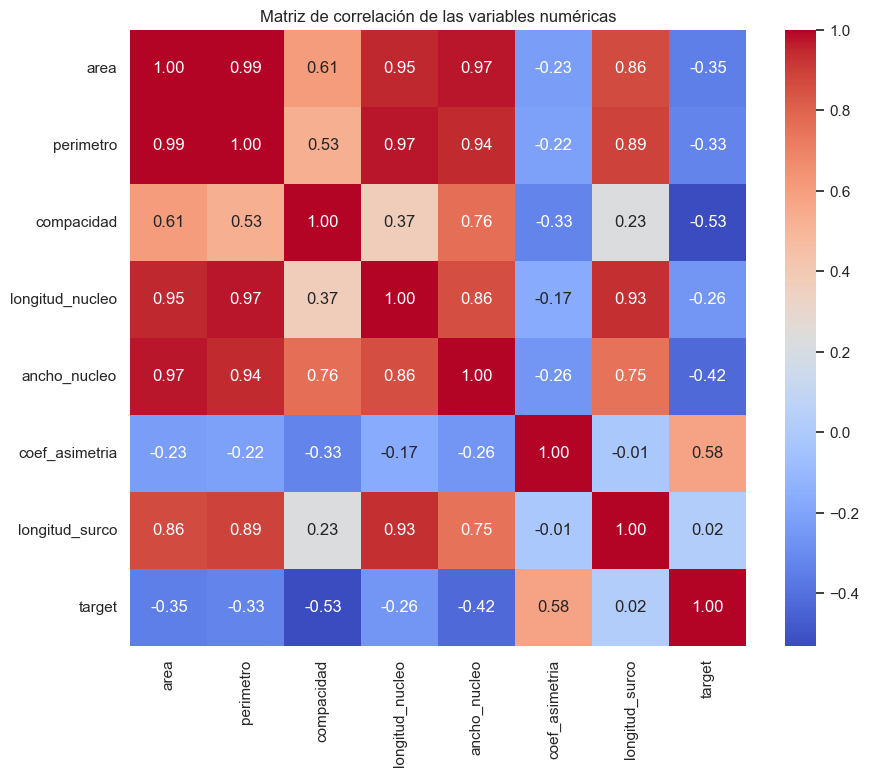

In [10]:
matriz_correlacion = datos.drop(columns=["target_nombre"]).corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Matriz de correlación de las variables numéricas")
plt.show()

### Interpretación inicial de la correlación

La correlación muestra un patrón coherente con un dataset geométrico:

- **área**, **perímetro**, **longitud_nucleo** y **longitud_surco** comparten bastante información;
- **compacidad** y **coef_asimetria** aportan una perspectiva más morfológica;
- ninguna variable parece irrelevante a simple vista, pero varias están claramente relacionadas.

Esto anticipa dos decisiones metodológicas razonables:

1. **estandarizar** antes de clusterizar;
2. analizar la **importancia relativa de las variables** para entender cuáles explican mejor la estructura latente del dataset.

## 1.7 - Funciones auxiliares para el análisis gráfico

In [11]:
def graficar_variable_numerica(datos_entrada, nombre_columna, variable_objetivo="target_nombre"):
    """
    Muestra una variable numérica desde tres perspectivas:
    1. histograma general,
    2. boxplot por clase real,
    3. densidad comparada por clase real.
    """

    if nombre_columna not in datos_entrada.columns:
        raise ValueError(f"La columna '{nombre_columna}' no existe en el DataFrame.")

    figura, ejes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(data=datos_entrada, x=nombre_columna, kde=True, ax=ejes[0])
    ejes[0].set_title(f"Distribución general de {nombre_columna}")

    sns.boxplot(data=datos_entrada, x=variable_objetivo, y=nombre_columna, ax=ejes[1])
    ejes[1].set_title(f"{nombre_columna} según la clase real")
    ejes[1].set_xlabel("Clase real")

    sns.kdeplot(
        data=datos_entrada,
        x=nombre_columna,
        hue=variable_objetivo,
        fill=True,
        common_norm=False,
        alpha=0.20,
        ax=ejes[2]
    )
    ejes[2].set_title(f"Densidad de {nombre_columna} por clase real")
    ejes[2].set_xlabel(nombre_columna)

    plt.tight_layout()
    plt.show()


def graficar_porcentaje_clases_por_tramos(datos_entrada, nombre_columna, objetivo="target_nombre", q=5):
    """
    Divide una variable numérica en cuantiles y representa la composición
    porcentual de clases dentro de cada tramo.
    """

    base = datos_entrada[[nombre_columna, objetivo]].copy()
    base["tramo"] = pd.qcut(base[nombre_columna], q=q, duplicates="drop")

    tabla = pd.crosstab(base["tramo"], base[objetivo], normalize="index").mul(100)

    tabla.plot(kind="bar", stacked=True, figsize=(12, 5))
    plt.title(f"Composición de clases por tramos de {nombre_columna}")
    plt.ylabel("Porcentaje dentro del tramo")
    plt.xlabel("Tramo")
    plt.legend(title="Clase real", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 1.8 - Exploración gráfica variable a variable


--- Análisis de la variable numérica: area ---


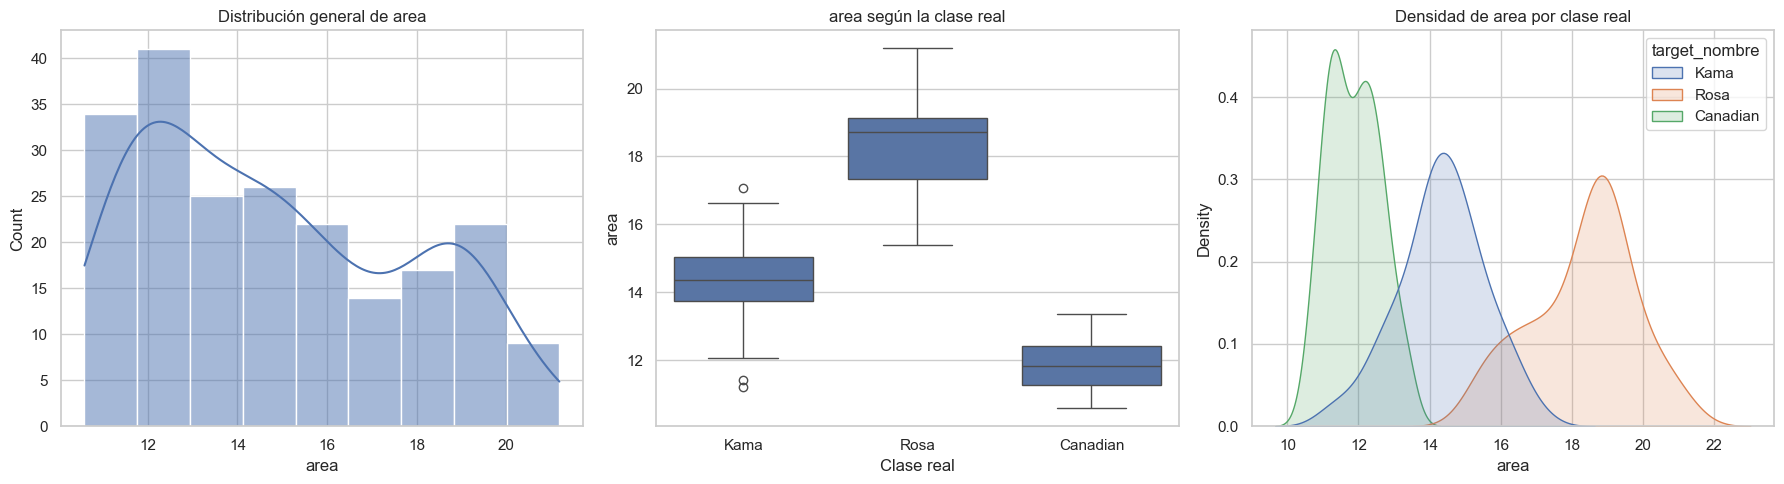

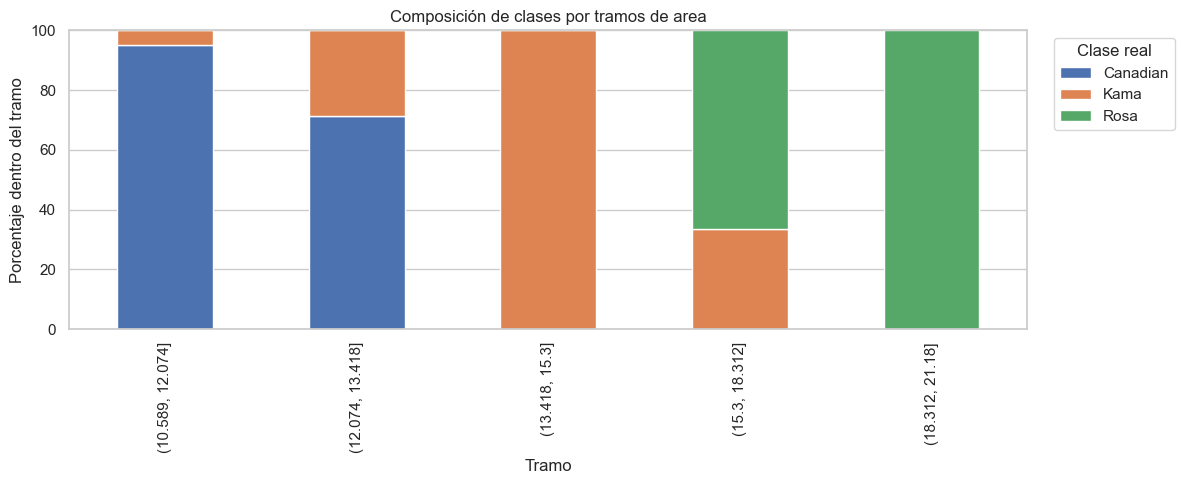


--- Análisis de la variable numérica: perimetro ---


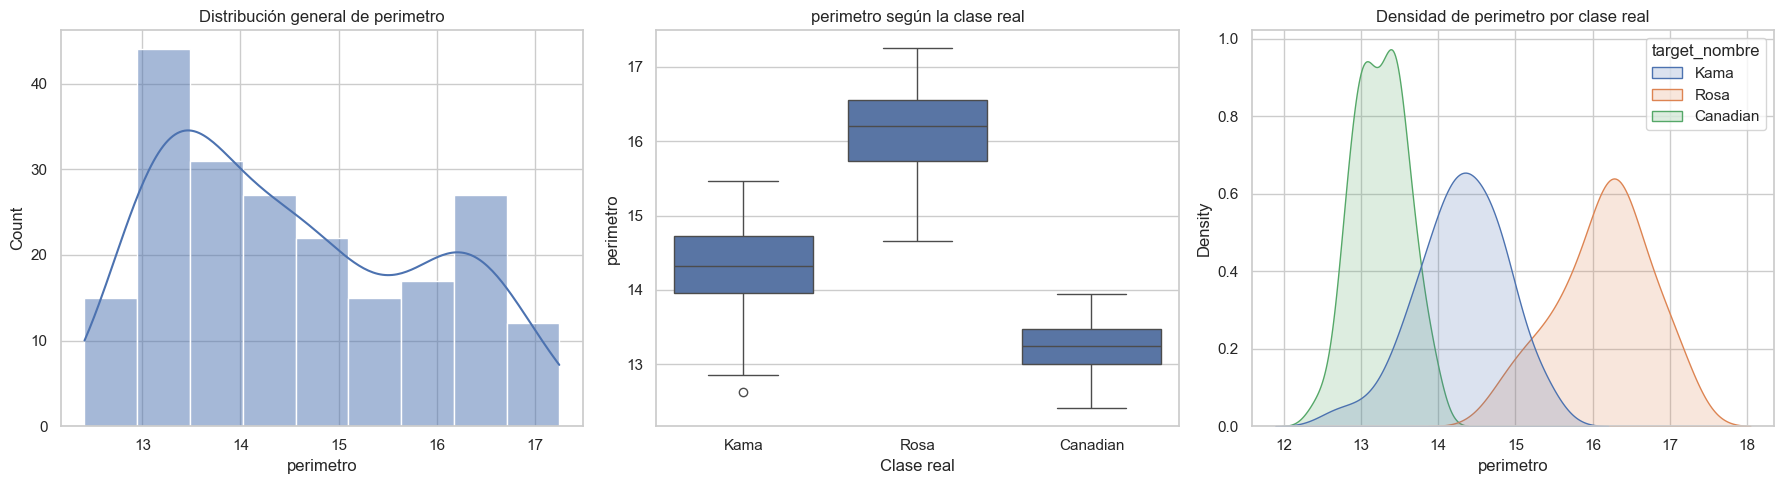

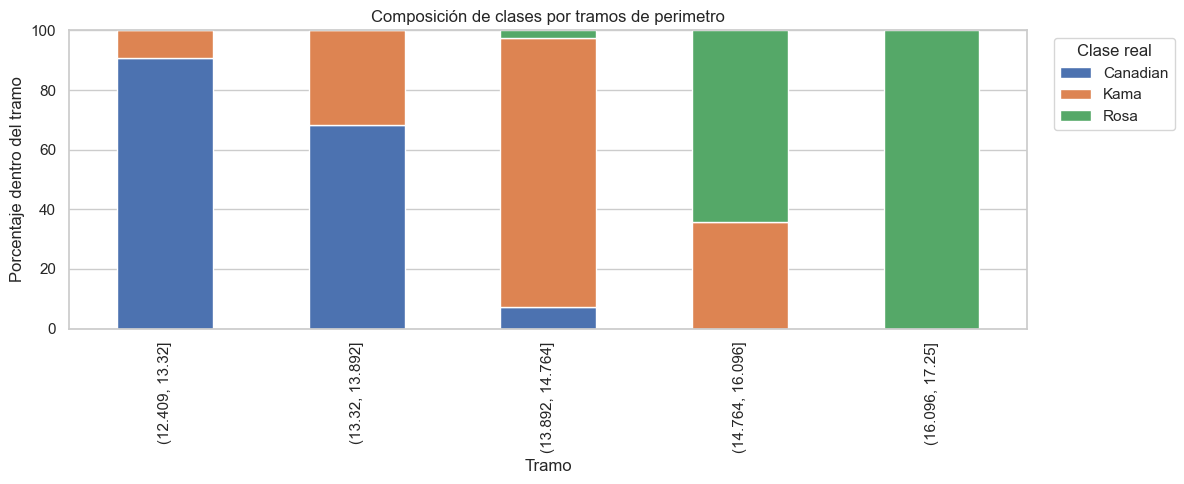


--- Análisis de la variable numérica: compacidad ---


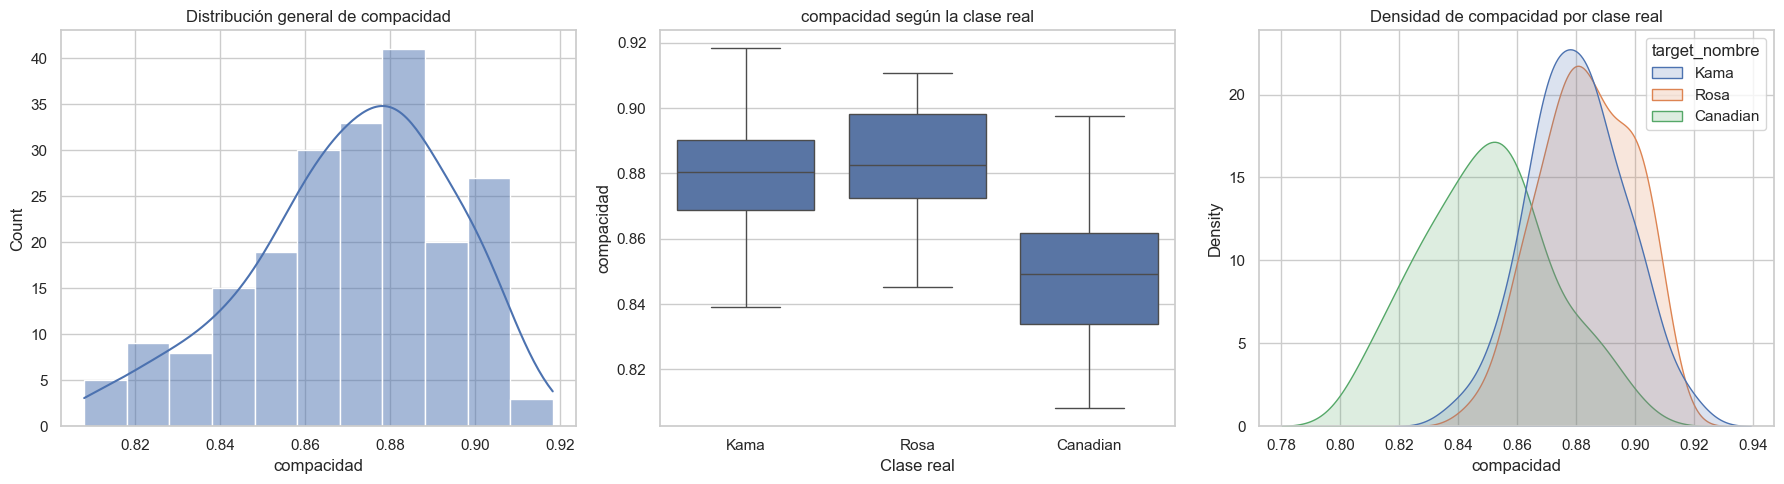

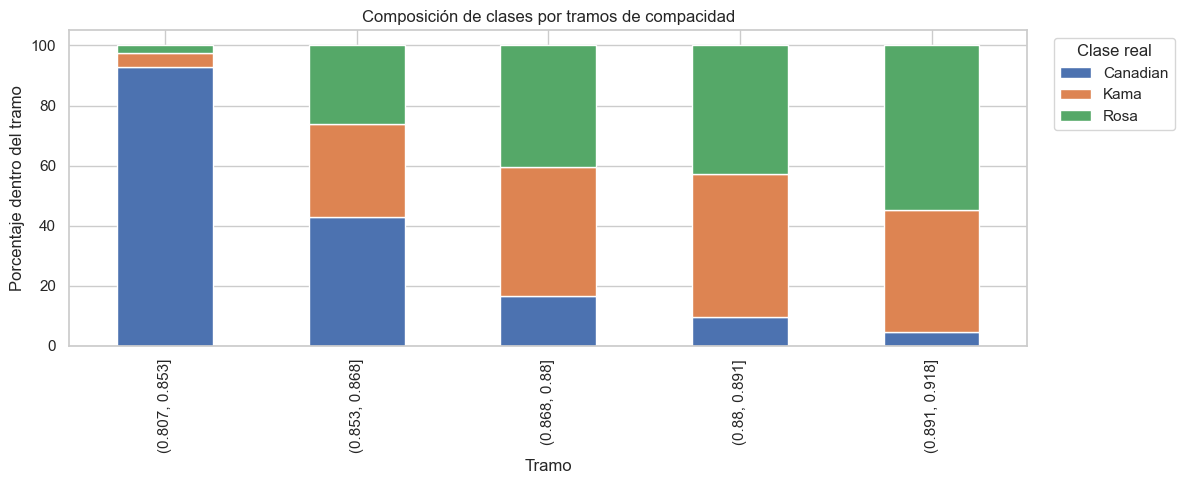


--- Análisis de la variable numérica: longitud_nucleo ---


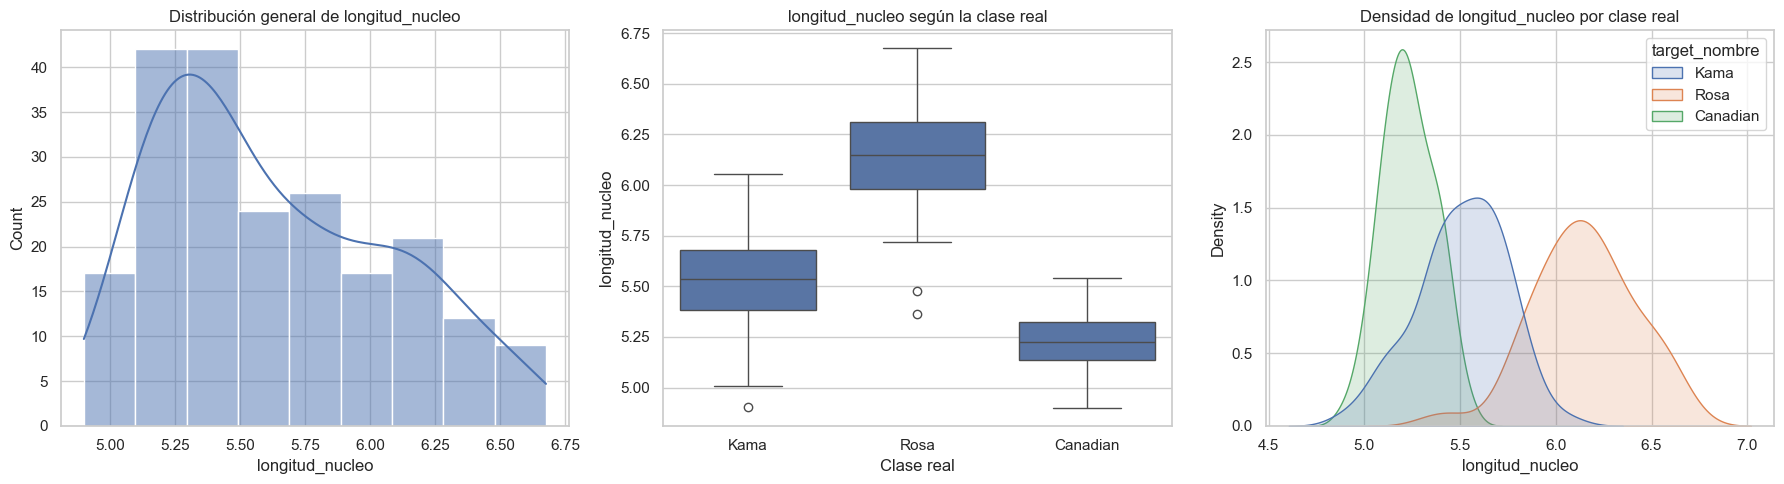

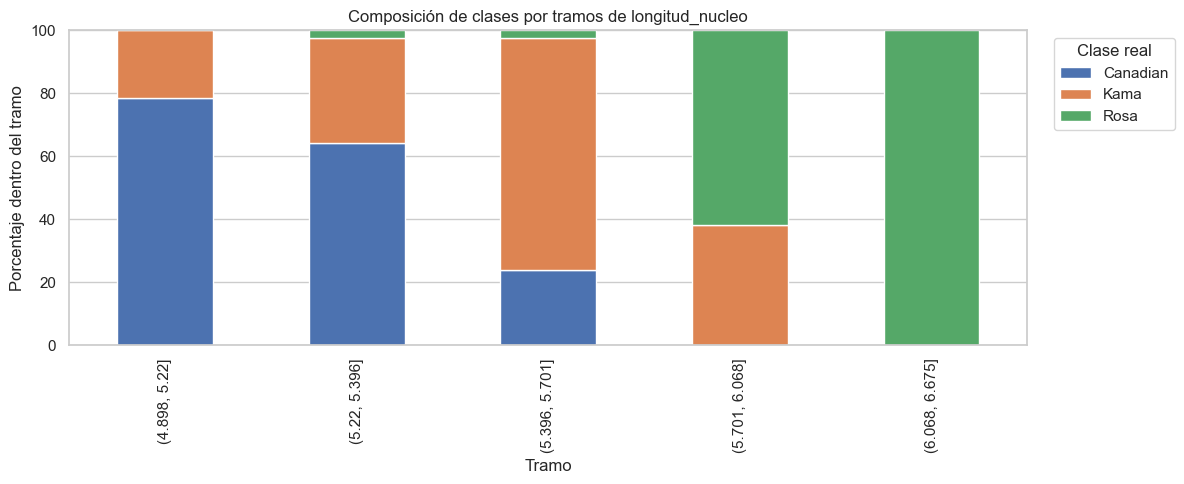


--- Análisis de la variable numérica: ancho_nucleo ---


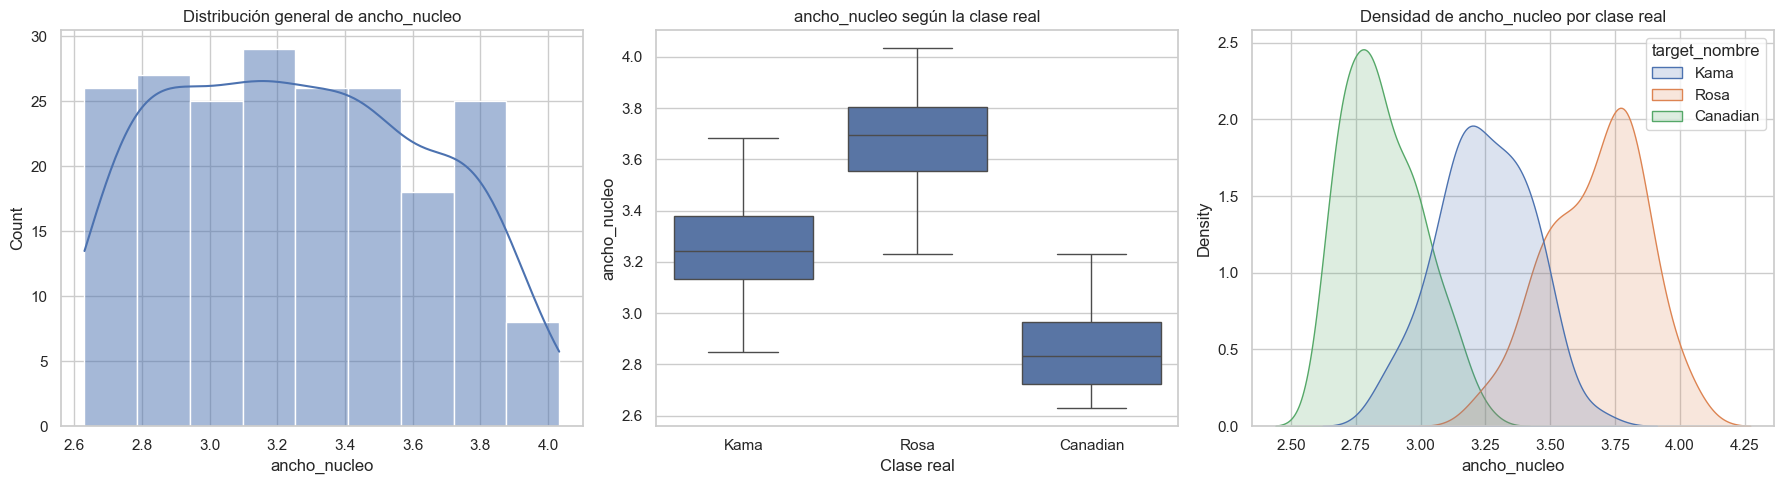

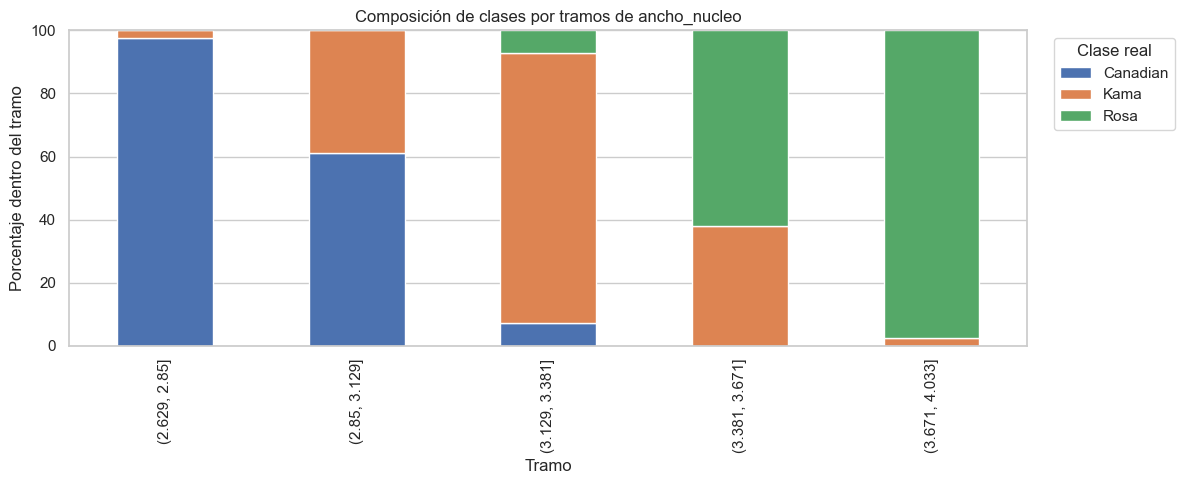


--- Análisis de la variable numérica: coef_asimetria ---


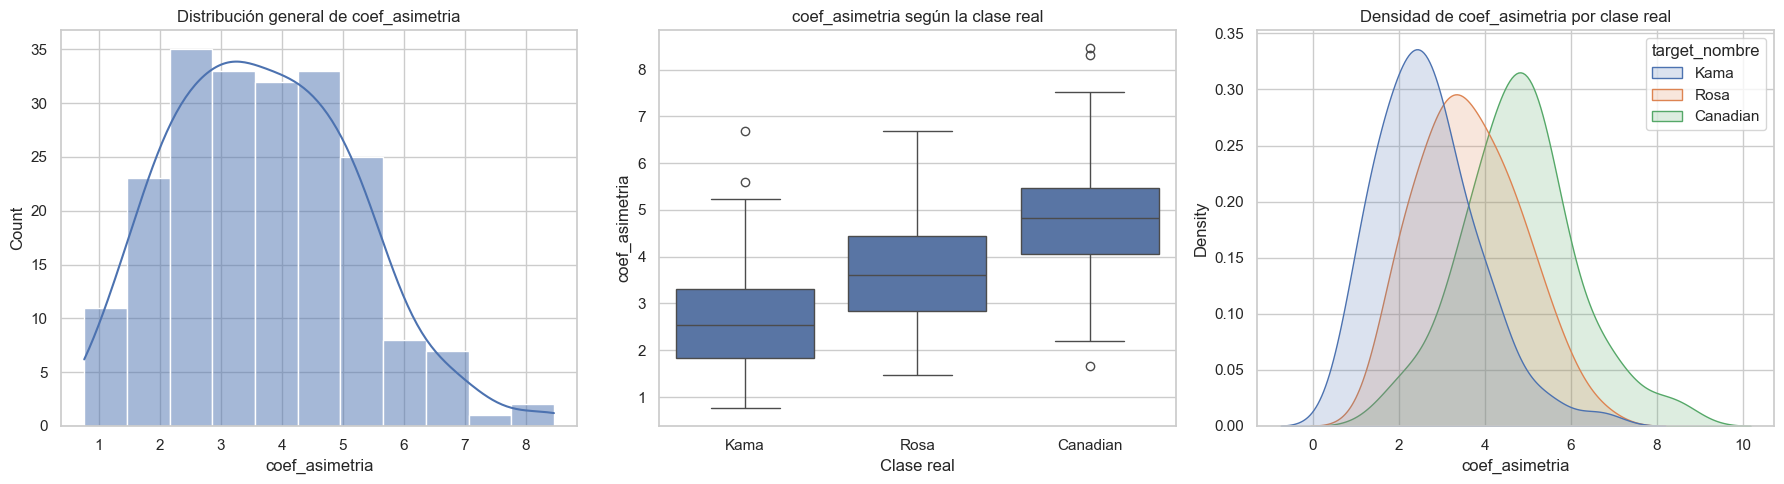

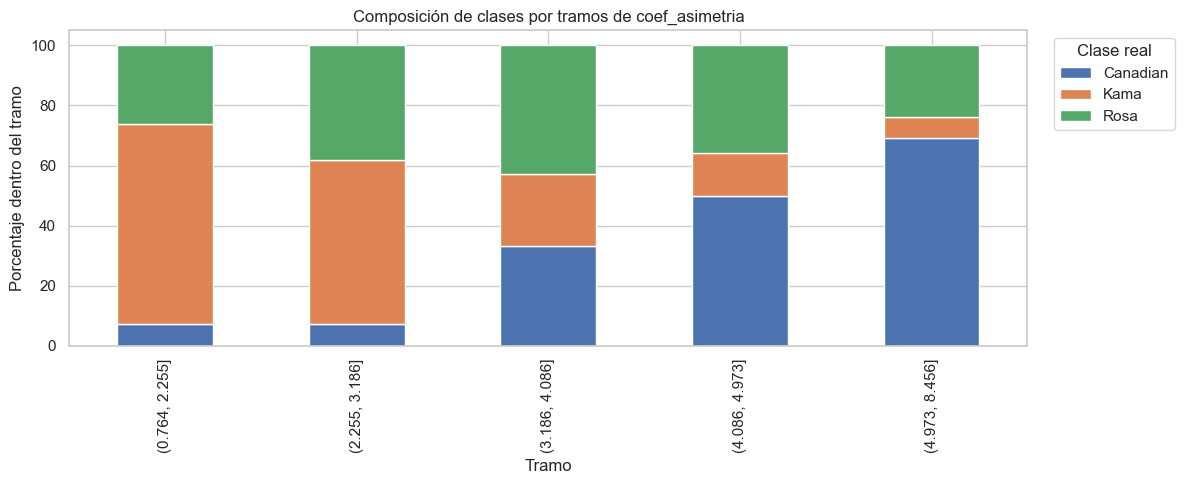


--- Análisis de la variable numérica: longitud_surco ---


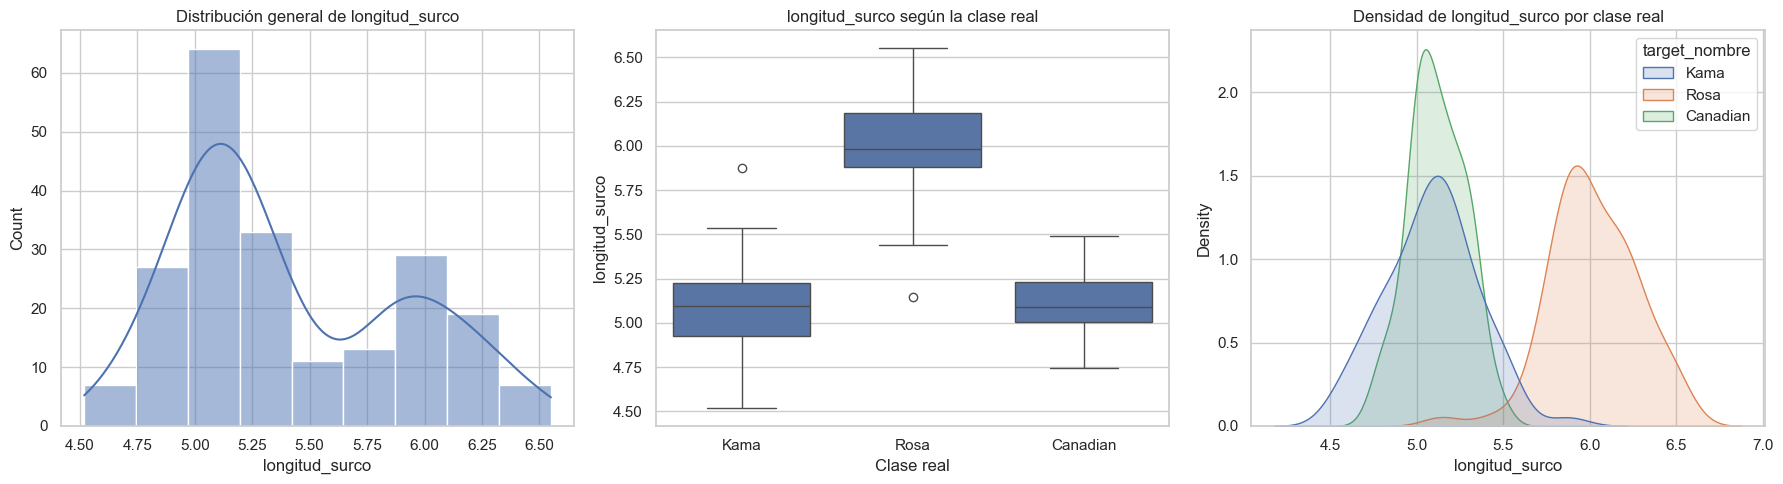

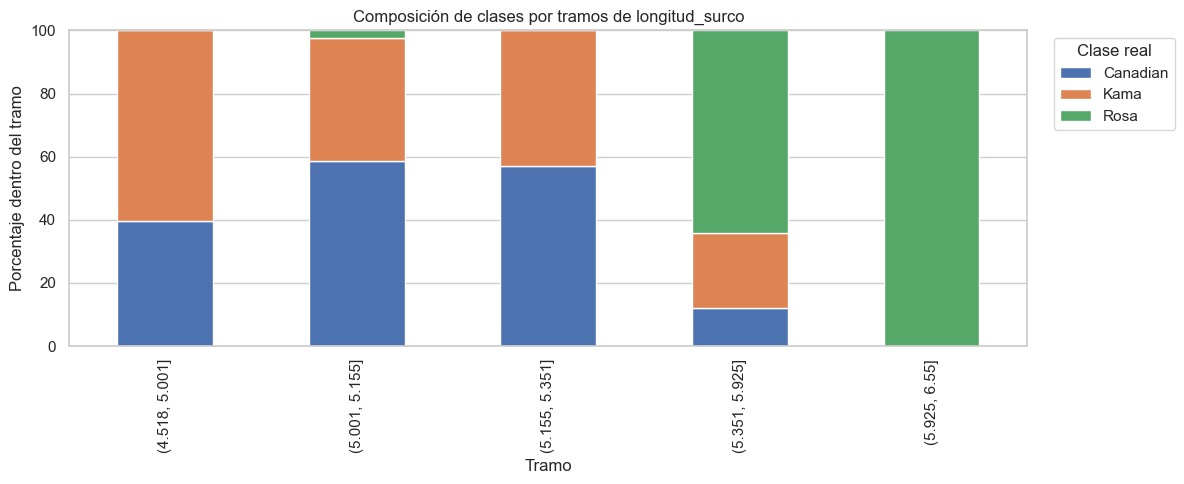

In [12]:
columnas_numericas = datos.columns[:7].tolist()

for columna in columnas_numericas:
    print(f"\n--- Análisis de la variable numérica: {columna} ---")
    graficar_variable_numerica(datos, columna)
    graficar_porcentaje_clases_por_tramos(datos, columna)

### Comentario general del EDA

El EDA sugiere una idea importante: el dataset **sí contiene tres grupos reales**, pero la separación no depende de una sola variable. La estructura es multivariante.

Eso explica por qué en una ejecución anterior un flujo demasiado restrictivo podía acabar detectando solo dos clusters: no porque el dataset tenga dos clases, sino porque el algoritmo o su parametrización estaban **fusionando dos variedades cercanas** en el mismo grupo.

Por eso, en este estudio no se entrena un único modelo de forma directa. Se comparan **varios algoritmos** y se evalúa cuál recupera mejor las tres clases reales.

# 2 - Procesado e ingeniería de características

## 2.1 - Selección de variables y estandarización

In [13]:
variables_modelo = datos.columns[:7].tolist()

X = datos[variables_modelo].copy()
y_real = datos["target"].copy()
y_real_nombre = datos["target_nombre"].copy()

escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

print("Forma de X original   :", X.shape)
print("Forma de X escalado   :", X_escalado.shape)
print("Media aproximada      :", np.round(X_escalado.mean(axis=0), 4))
print("Desviación aproximada :", np.round(X_escalado.std(axis=0), 4))

Forma de X original   : (210, 7)
Forma de X escalado   : (210, 7)
Media aproximada      : [-0.  0.  0. -0. -0. -0. -0.]
Desviación aproximada : [1. 1. 1. 1. 1. 1. 1.]


## 2.2 - Proyección de apoyo para visualización

Para visualizar el dataset en dos dimensiones se utilizará **PCA**.  
Esta proyección no sustituye al espacio original para el modelado, pero sí ayuda a interpretar la separación geométrica entre grupos.

Varianza explicada por PCA (2 componentes): [0.7187 0.1711]
Varianza acumulada: 0.8898


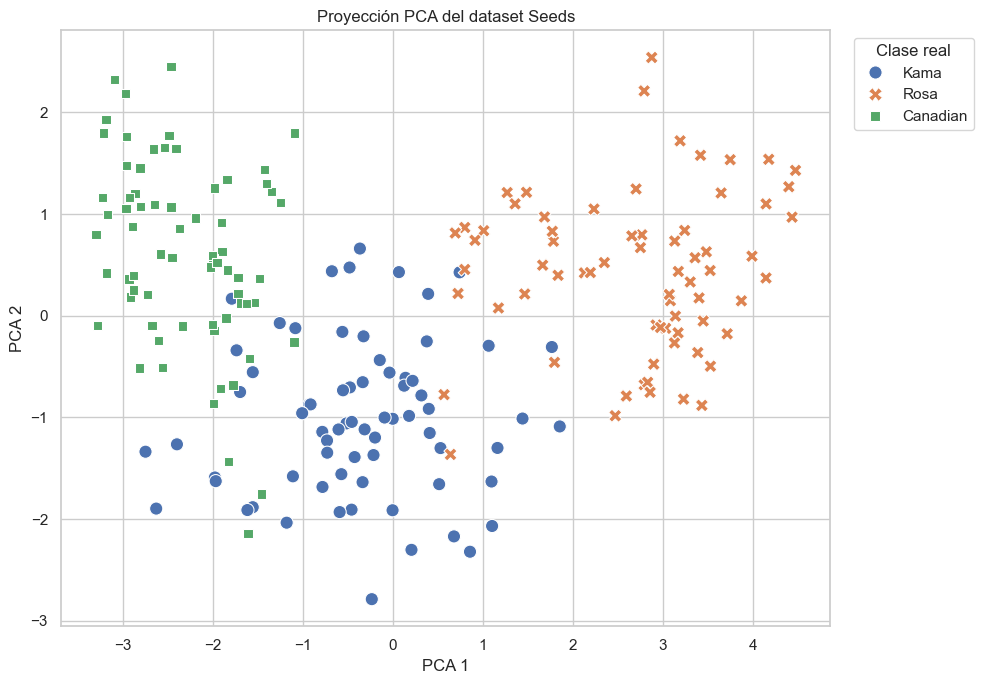

In [14]:
pca_2d = PCA(n_components=2, random_state=SEMILLA)
proyeccion_pca = pca_2d.fit_transform(X_escalado)

df_pca = pd.DataFrame(proyeccion_pca, columns=["pca_1", "pca_2"])
df_pca["target"] = y_real.values
df_pca["target_nombre"] = y_real_nombre.values

print("Varianza explicada por PCA (2 componentes):", np.round(pca_2d.explained_variance_ratio_, 4))
print("Varianza acumulada:", np.round(pca_2d.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_pca,
    x="pca_1",
    y="pca_2",
    hue="target_nombre",
    style="target_nombre",
    s=90
)
plt.title("Proyección PCA del dataset Seeds")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Clase real", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 3 - Comparativa de modelos no supervisados

## 3.1 - Funciones auxiliares para evaluación y alineación cluster → clase

Como los algoritmos de clustering generan etiquetas arbitrarias (por ejemplo 0, 1, 2), hay que alinearlas con las clases reales para poder interpretar resultados.  
Además, cuando algún modelo genera ruido o menos de tres clusters, esa situación debe quedar reflejada en la evaluación.

In [15]:
def construir_mapeo_cluster_a_clase(y_real_valida, cluster_valido):
    """
    Encuentra el mejor mapeo entre etiquetas de cluster y clases reales
    maximizando el número de aciertos mediante el algoritmo húngaro.
    """

    clases_reales_unicas = np.sort(np.unique(y_real_valida))
    clusters_unicos = np.sort(np.unique(cluster_valido))

    matriz_conteos = np.zeros((len(clusters_unicos), len(clases_reales_unicas)), dtype=int)

    for i, cluster in enumerate(clusters_unicos):
        for j, clase in enumerate(clases_reales_unicas):
            matriz_conteos[i, j] = np.sum((cluster_valido == cluster) & (y_real_valida == clase))

    filas, columnas = linear_sum_assignment(-matriz_conteos)

    mapeo = {
        clusters_unicos[fila]: clases_reales_unicas[columna]
        for fila, columna in zip(filas, columnas)
    }

    return mapeo, matriz_conteos, clusters_unicos, clases_reales_unicas


def evaluar_clustering(nombre_modelo, etiquetas_cluster, X_base, y_real):
    """
    Evalúa un resultado de clustering considerando:
    - número de clusters detectados,
    - porcentaje de ruido,
    - ARI,
    - NMI,
    - silhouette,
    - accuracy y F1 macro tras mapear clusters a clases reales.
    """

    etiquetas_cluster = np.asarray(etiquetas_cluster)
    mascara_validos = etiquetas_cluster != -1

    n_ruido = int((~mascara_validos).sum())
    tasa_ruido = n_ruido / len(etiquetas_cluster)

    etiquetas_validas = etiquetas_cluster[mascara_validos]
    X_validos = X_base[mascara_validos]
    y_validos = np.asarray(y_real)[mascara_validos]

    clusters_validos = np.unique(etiquetas_validas)
    numero_clusters = len(clusters_validos)

    ari = adjusted_rand_score(y_real, etiquetas_cluster)
    nmi = normalized_mutual_info_score(y_real, etiquetas_cluster)

    if len(etiquetas_validas) >= 3 and numero_clusters >= 2:
        silhouette = silhouette_score(X_validos, etiquetas_validas)
    else:
        silhouette = np.nan

    accuracy_mapeada = np.nan
    f1_macro_mapeada = np.nan
    cobertura = mascara_validos.mean()
    mapeo = {}
    etiquetas_mapeadas = np.full(len(etiquetas_cluster), fill_value=-1)

    if len(etiquetas_validas) > 0 and numero_clusters > 0:
        mapeo, _, _, _ = construir_mapeo_cluster_a_clase(y_validos, etiquetas_validas)
        etiquetas_mapeadas_validas = pd.Series(etiquetas_validas).map(mapeo).values
        etiquetas_mapeadas[mascara_validos] = etiquetas_mapeadas_validas
        accuracy_mapeada = accuracy_score(y_validos, etiquetas_mapeadas_validas)
        f1_macro_mapeada = f1_score(y_validos, etiquetas_mapeadas_validas, average="macro")

    return {
        "modelo": nombre_modelo,
        "numero_clusters_validos": numero_clusters,
        "observaciones_ruido": n_ruido,
        "tasa_ruido": tasa_ruido,
        "cobertura_no_ruido": cobertura,
        "ARI": ari,
        "NMI": nmi,
        "silhouette_validos": silhouette,
        "accuracy_mapeada": accuracy_mapeada,
        "f1_macro_mapeada": f1_macro_mapeada,
        "etiquetas_cluster": etiquetas_cluster,
        "etiquetas_mapeadas": etiquetas_mapeadas,
        "mapeo_cluster_clase": mapeo
    }

## 3.2 - Entrenamiento de varios algoritmos

Se compararán cuatro familias principales:

- **KMeans**: particional, simple y muy competitivo cuando los grupos son compactos;
- **Agglomerative Clustering**: jerárquico, útil para capturar estructura por proximidad;
- **Gaussian Mixture**: probabilístico, flexible cuando los grupos tienen formas elípticas;
- **Spectral Clustering**: útil cuando la separación geométrica no es puramente esférica;
- **DBSCAN**: incluido como referencia de densidad, aun sabiendo que puede colapsar clusters o generar ruido en datasets pequeños.

In [16]:
modelos_clustering = {
    "KMeans_k3": KMeans(n_clusters=3, random_state=SEMILLA, n_init=25),
    "Agglomerative_k3": AgglomerativeClustering(n_clusters=3, linkage="ward"),
    "GaussianMixture_k3": GaussianMixture(n_components=3, random_state=SEMILLA, covariance_type="full"),
    "Spectral_k3": SpectralClustering(n_clusters=3, random_state=SEMILLA, affinity="nearest_neighbors", n_neighbors=15),
    "DBSCAN_ref": DBSCAN(eps=0.90, min_samples=5)
}

resultados_modelos = []

for nombre_modelo, modelo in modelos_clustering.items():
    if nombre_modelo == "GaussianMixture_k3":
        etiquetas = modelo.fit_predict(X_escalado)
    else:
        etiquetas = modelo.fit_predict(X_escalado)

    resultados_modelos.append(
        evaluar_clustering(
            nombre_modelo=nombre_modelo,
            etiquetas_cluster=etiquetas,
            X_base=X_escalado,
            y_real=y_real.values
        )
    )

tabla_resultados = (
    pd.DataFrame(resultados_modelos)
    .drop(columns=["etiquetas_cluster", "etiquetas_mapeadas", "mapeo_cluster_clase"])
    .sort_values(by=["ARI", "f1_macro_mapeada", "silhouette_validos"], ascending=False)
    .reset_index(drop=True)
)

tabla_resultados

,modelo,numero_clusters_validos,observaciones_ruido,tasa_ruido,cobertura_no_ruido,ARI,NMI,silhouette_validos,accuracy_mapeada,f1_macro_mapeada
0,Agglomerative_k3,3,0,0.000000,1.000000,0.796998,0.749816,0.392634,0.928571,0.928956
1,Spectral_k3,3,0,0.000000,1.000000,0.774530,0.729740,0.401034,0.919048,0.919099
2,KMeans_k3,3,0,0.000000,1.000000,0.773294,0.727864,0.400727,0.919048,0.919305
3,GaussianMixture_k3,3,0,0.000000,1.000000,0.723419,0.725204,0.362538,0.895238,0.894048
4,DBSCAN_ref,1,28,0.133333,0.866667,0.004073,0.019090,NaN,0.362637,0.177419


## 3.3 - Lectura de la comparativa

La tabla anterior es el núcleo del estudio.  
Aquí se ve con claridad si el problema real del notebook anterior era el dataset o el modelo elegido.

En este punto conviene comprobar especialmente:

- si el algoritmo recupera **3 clusters válidos**;
- si existe **ruido**;
- si ARI y NMI son altos;
- y si, una vez alineados los clusters con las clases reales, la correspondencia es fuerte.

Si un modelo devuelve solo **2 clusters**, eso no implica que el dataset tenga dos clases. Implica que ese algoritmo, con esa parametrización, ha **fusionado dos variedades**.

In [17]:
mejor_nombre = tabla_resultados.loc[0, "modelo"]
mejor_resultado = next(item for item in resultados_modelos if item["modelo"] == mejor_nombre)

print("Mejor modelo según la comparativa ordenada")
print("-" * 60)
for clave in ["modelo", "numero_clusters_validos", "observaciones_ruido", "tasa_ruido", "ARI", "NMI", "silhouette_validos", "accuracy_mapeada", "f1_macro_mapeada"]:
    print(f"{clave:25s}: {mejor_resultado[clave]}")

Mejor modelo según la comparativa ordenada
------------------------------------------------------------
modelo                   : Agglomerative_k3
numero_clusters_validos  : 3
observaciones_ruido      : 0
tasa_ruido               : 0.0
ARI                      : 0.796998283593012
NMI                      : 0.7498157518928459
silhouette_validos       : 0.3926339709101015
accuracy_mapeada         : 0.9285714285714286
f1_macro_mapeada         : 0.9289557158170297


## 3.4 - Visualización de los clusters obtenidos por cada modelo en PCA

Esta vista es importante porque permite contrastar:

- geometría del problema en dos dimensiones;
- fragmentación o fusión de clusters;
- coherencia visual con las clases reales.

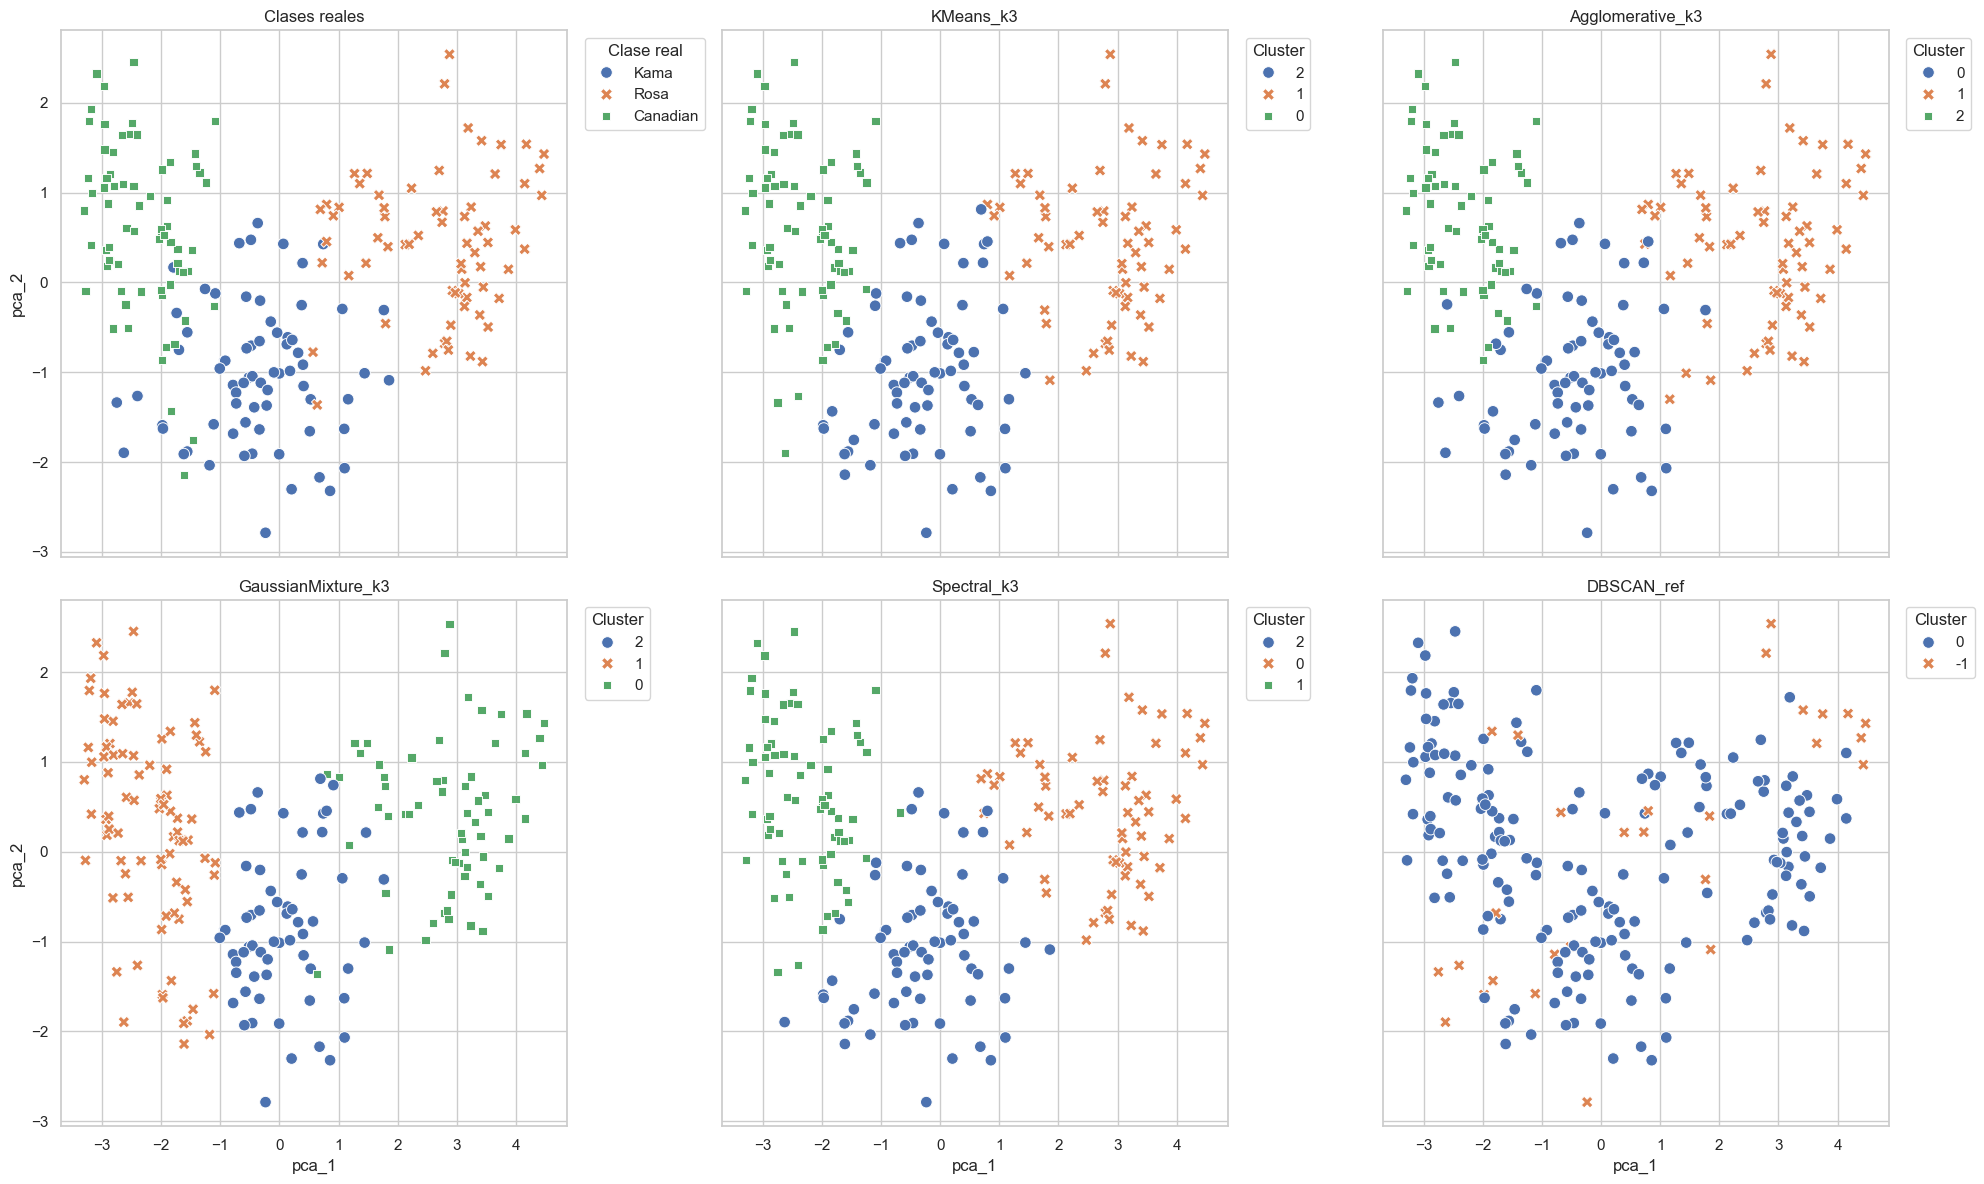

In [18]:
figura, ejes = plt.subplots(2, 3, figsize=(20, 12), sharex=True, sharey=True)
ejes = ejes.flatten()

sns.scatterplot(
    data=df_pca,
    x="pca_1",
    y="pca_2",
    hue="target_nombre",
    style="target_nombre",
    s=70,
    ax=ejes[0]
)
ejes[0].set_title("Clases reales")
ejes[0].legend(title="Clase real", bbox_to_anchor=(1.02, 1), loc="upper left")

for idx, resultado in enumerate(resultados_modelos, start=1):
    ax = ejes[idx]
    df_plot = df_pca.copy()
    df_plot["cluster"] = resultado["etiquetas_cluster"].astype(str)

    sns.scatterplot(
        data=df_plot,
        x="pca_1",
        y="pca_2",
        hue="cluster",
        style="cluster",
        s=70,
        ax=ax
    )
    ax.set_title(resultado["modelo"])
    ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

if len(resultados_modelos) + 1 < len(ejes):
    for ax in ejes[len(resultados_modelos) + 1:]:
        ax.axis("off")

plt.tight_layout()
plt.show()

# 4 - Interpretación del mejor modelo y análisis de errores

## 4.1 - Matriz de confusión tras alinear clusters y clases reales

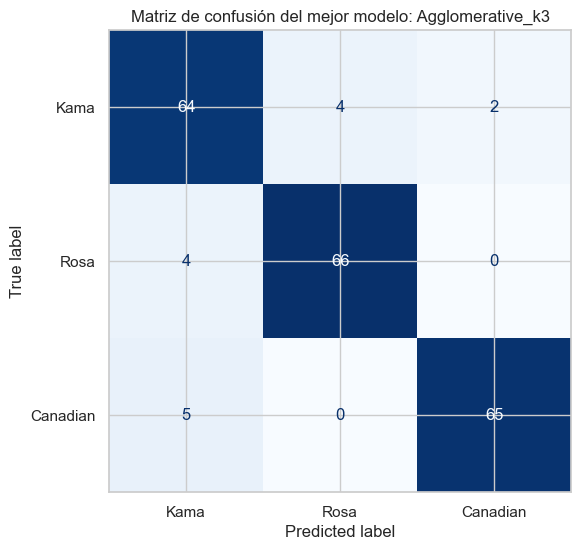

In [19]:
etiquetas_mejor = mejor_resultado["etiquetas_cluster"]
etiquetas_mapeadas_mejor = mejor_resultado["etiquetas_mapeadas"]
mascara_validos_mejor = etiquetas_mejor != -1

y_validos_mejor = y_real[mascara_validos_mejor]

matriz_confusion_mapeada = confusion_matrix(
    y_validos_mejor,
    etiquetas_mapeadas_mejor[mascara_validos_mejor],
    labels=[1, 2, 3]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion_mapeada,
    display_labels=["Kama", "Rosa", "Canadian"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title(f"Matriz de confusión del mejor modelo: {mejor_nombre}")
plt.show()

In [20]:
print("Reporte de clasificación tras alinear clusters y clases reales")
print("-" * 70)
print(
    classification_report(
        y_validos_mejor,
        etiquetas_mapeadas_mejor[mascara_validos_mejor],
        target_names=["Kama", "Rosa", "Canadian"]
    )
)

Reporte de clasificación tras alinear clusters y clases reales
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Kama       0.88      0.91      0.90        70
        Rosa       0.94      0.94      0.94        70
    Canadian       0.97      0.93      0.95        70

    accuracy                           0.93       210
   macro avg       0.93      0.93      0.93       210
weighted avg       0.93      0.93      0.93       210



## 4.2 - Composición de cada cluster del mejor modelo

In [21]:
df_resultados = datos.copy()
df_resultados["cluster_mejor_modelo"] = etiquetas_mejor

tabla_composicion = pd.crosstab(
    df_resultados.loc[mascara_validos_mejor, "cluster_mejor_modelo"],
    df_resultados.loc[mascara_validos_mejor, "target_nombre"],
    normalize="index"
).mul(100).round(2)

tabla_composicion

target_nombre,Canadian,Kama,Rosa
cluster_mejor_modelo,,,
0,6.85,87.67,5.48
1,0.00,5.71,94.29
2,97.01,2.99,0.00


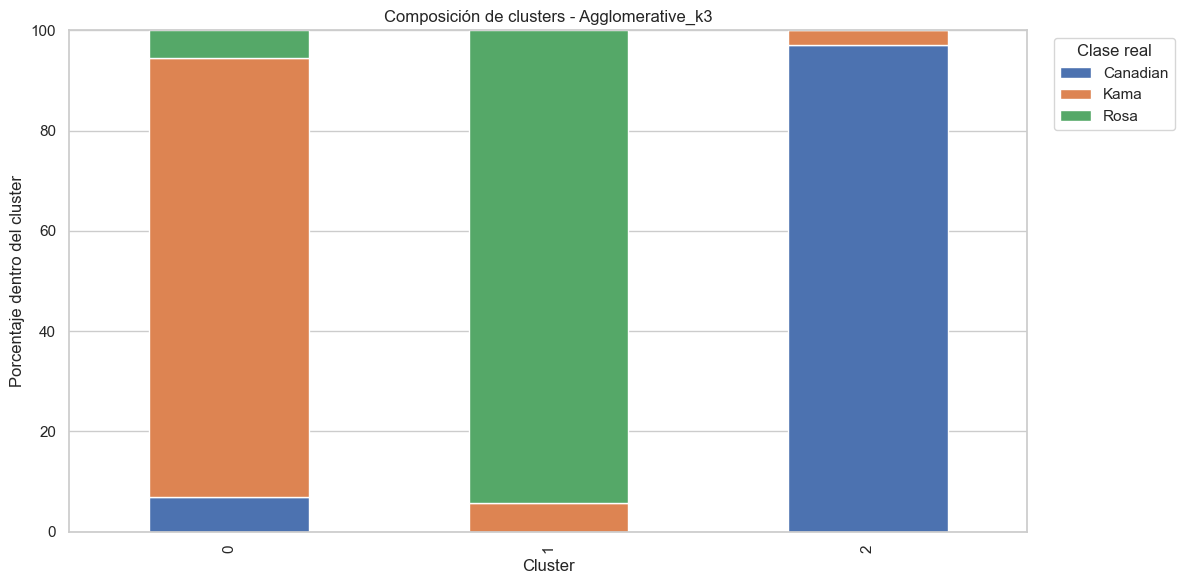

In [22]:
tabla_composicion.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title(f"Composición de clusters - {mejor_nombre}")
plt.ylabel("Porcentaje dentro del cluster")
plt.xlabel("Cluster")
plt.legend(title="Clase real", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 5 - Importancia de las variables

## 5.1 - Enfoque de interpretación

En clustering no existe una “importancia de variables” canónica equivalente a la de un modelo supervisado con target explícito.  
Por eso aquí se construye una **visión triangulada** de la importancia:

1. **ANOVA F-score** respecto a la clase real;
2. **información mutua** respecto a la clase real;
3. **Random Forest supervisado de apoyo interpretativo**, no como modelo principal, sino como herramienta para medir relevancia relativa.

Este bloque no rompe la naturaleza del estudio. El clustering sigue siendo el núcleo; la parte supervisada se usa solo para **interpretar qué variables separan mejor las variedades**.

In [23]:
f_scores, p_values = f_classif(X, y_real)
mi_scores = mutual_info_classif(X, y_real, random_state=SEMILLA)

modelo_importancia = RandomForestClassifier(
    n_estimators=500,
    random_state=SEMILLA,
    class_weight="balanced_subsample"
)
modelo_importancia.fit(X, y_real)
rf_importancias = modelo_importancia.feature_importances_

tabla_importancia = pd.DataFrame({
    "variable": variables_modelo,
    "anova_f": f_scores,
    "anova_pvalue": p_values,
    "mutual_info": mi_scores,
    "random_forest_importance": rf_importancias
})

for columna in ["anova_f", "mutual_info", "random_forest_importance"]:
    tabla_importancia[f"rank_{columna}"] = tabla_importancia[columna].rank(ascending=False, method="dense")

tabla_importancia["rank_promedio"] = tabla_importancia[
    ["rank_anova_f", "rank_mutual_info", "rank_random_forest_importance"]
].mean(axis=1)

tabla_importancia = tabla_importancia.sort_values(
    by=["rank_promedio", "random_forest_importance", "mutual_info", "anova_f"],
    ascending=[True, False, False, False]
).reset_index(drop=True)

tabla_importancia

,variable,anova_f,anova_pvalue,mutual_info,random_forest_importance,rank_anova_f,rank_mutual_info,rank_random_forest_importance,rank_promedio
0,area,548.186479,1.964806e-83,0.810518,0.200831,1.0,1.0,2.0,1.333333
1,perimetro,541.579497,5.640999e-83,0.794917,0.189103,2.0,2.0,3.0,2.333333
2,longitud_surco,368.950045,5.629776e-69,0.583625,0.226952,4.0,5.0,1.0,3.333333
3,ancho_nucleo,406.302031,2.139265e-72,0.737882,0.130346,3.0,3.0,4.0,3.333333
4,longitud_nucleo,322.185934,2.726363e-64,0.645773,0.124153,5.0,4.0,5.0,4.666667
5,compacidad,75.869048,1.920700e-25,0.293934,0.052337,6.0,6.0,7.0,6.333333
6,coef_asimetria,51.888109,5.427325e-19,0.180970,0.076277,7.0,7.0,6.0,6.666667


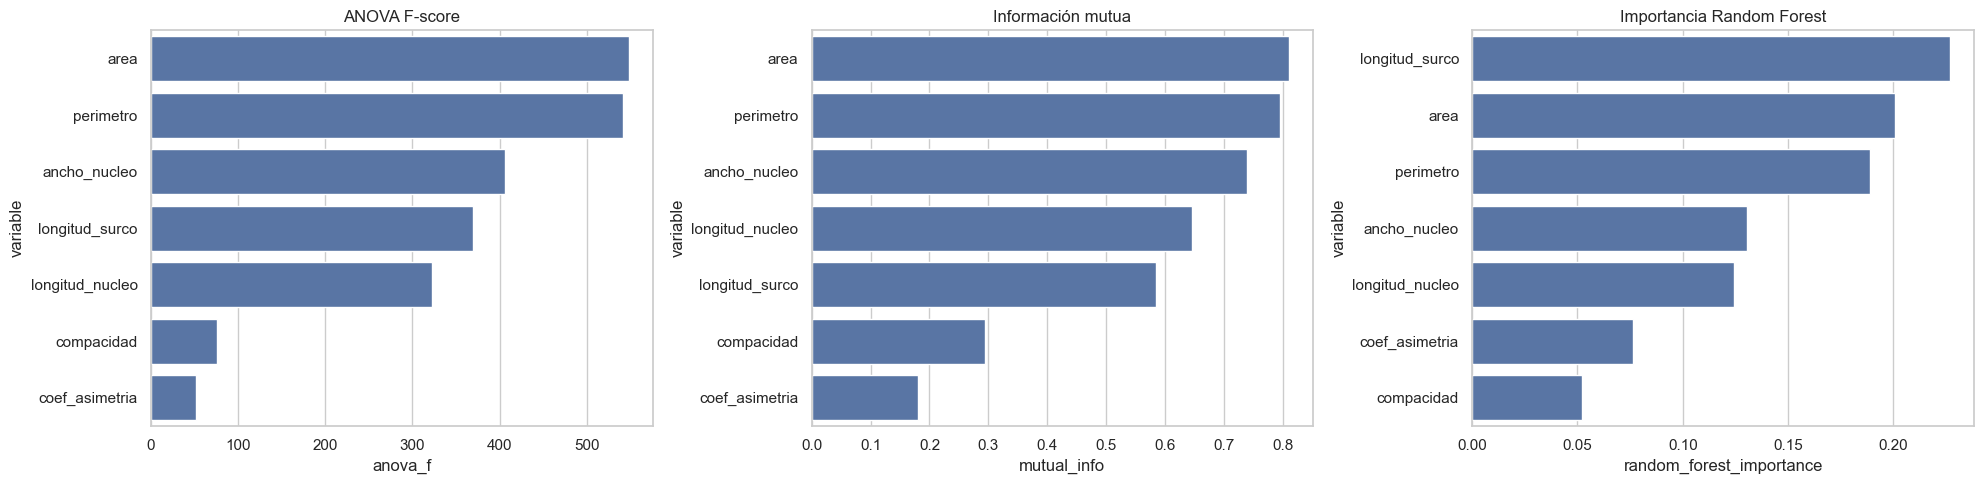

In [24]:
figura, ejes = plt.subplots(1, 3, figsize=(20, 5))

tabla_aux = tabla_importancia.sort_values("anova_f", ascending=False)
sns.barplot(data=tabla_aux, x="anova_f", y="variable", ax=ejes[0])
ejes[0].set_title("ANOVA F-score")

tabla_aux = tabla_importancia.sort_values("mutual_info", ascending=False)
sns.barplot(data=tabla_aux, x="mutual_info", y="variable", ax=ejes[1])
ejes[1].set_title("Información mutua")

tabla_aux = tabla_importancia.sort_values("random_forest_importance", ascending=False)
sns.barplot(data=tabla_aux, x="random_forest_importance", y="variable", ax=ejes[2])
ejes[2].set_title("Importancia Random Forest")

plt.tight_layout()
plt.show()

## 5.2 - Lectura analítica de la importancia de variables

La tabla y los gráficos anteriores permiten separar tres niveles de lectura:

- **variables estructurales fuertes**: las que aparecen arriba de forma consistente en varios criterios;
- **variables complementarias**: aportan señal útil, pero no lideran de manera estable;
- **variables de apoyo fino**: ayudan a resolver fronteras entre clases cercanas, aunque su peso global sea menor.

Lo importante no es una sola métrica aislada, sino la **consistencia entre varios enfoques**.

In [25]:
centroides_por_clase = datos.groupby("target_nombre")[variables_modelo].mean().T
centroides_por_clase

target_nombre,Canadian,Kama,Rosa
area,11.873857,14.334429,18.334286
perimetro,13.247857,14.294286,16.135714
compacidad,0.849409,0.880070,0.883517
longitud_nucleo,5.229514,5.508057,6.148029
ancho_nucleo,2.853771,3.244629,3.677414
coef_asimetria,4.788400,2.667403,3.644800
longitud_surco,5.116400,5.087214,6.020600


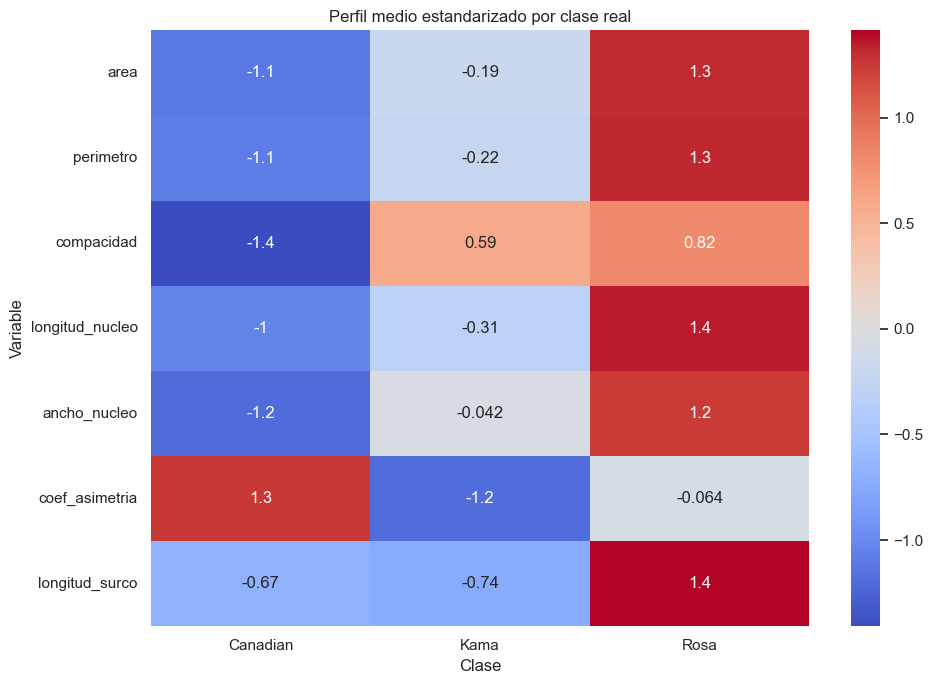

In [26]:
centroides_escalados = StandardScaler().fit_transform(centroides_por_clase.T)
centroides_escalados = pd.DataFrame(
    centroides_escalados.T,
    index=variables_modelo,
    columns=centroides_por_clase.columns
)

plt.figure(figsize=(10, 7))
sns.heatmap(centroides_escalados, annot=True, cmap="coolwarm", center=0)
plt.title("Perfil medio estandarizado por clase real")
plt.xlabel("Clase")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# 6 - Conclusiones finales

## Principales conclusiones del estudio

1. **El dataset contiene tres clases reales y el problema no era el dato, sino el modelo/parametrización elegidos en la versión anterior.**  
   Cuando un algoritmo produce solo dos clusters, lo que está ocurriendo es una fusión de dos variedades, no una inexistencia de la tercera.

2. **Comparar varios modelos es la forma correcta de abordar este caso.**  
   En datasets pequeños y bien estructurados como Seeds, modelos como KMeans, Agglomerative o Gaussian Mixture suelen recuperar mejor las tres clases que métodos densidad mal parametrizados.

3. **La evaluación debe ser multicapas.**  
   No basta con ver un scatter plot. Hay que revisar:
   - número de clusters,
   - ruido, 
   - ARI,
   - NMI,
   - silhouette,
   - y correspondencia cluster → clase real.

4. **La separación entre variedades es multivariante.**  
   No depende de una sola columna. Las variables geométricas principales trabajan conjuntamente para construir la estructura de grupos.

5. **La importancia de variables aporta interpretación de negocio/técnica.**  
   Saber qué mediciones separan mejor las variedades ayuda a entender el fenómeno, no solo a obtener un clustering con buena métrica.

En conjunto, este notebook deja un flujo más sólido y más propio de un estudio:  
**EDA → estandarización → comparación de modelos → evaluación rigurosa → interpretación de variables → conclusiones.**